In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay

In [5]:
# Load and Inspect Dataset
df = pd.read_csv("/content/train.csv", sep=',', engine='python', on_bad_lines='skip')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [6]:
# Encode Categorical Columns
categorical_cols = df.select_dtypes(include='object').columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [7]:
df.dropna(inplace= True)

In [8]:
df

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,16406,12320,3,84,308,10205,12,6011,1824.843333,3,...,3,12062,26.822620,180,1,49.574949,81513,3,42380,0
4,16452,12320,7,84,308,10205,12,6011,1824.843333,3,...,1,12062,24.797347,186,1,49.574949,55363,2,51834,0
6,16476,12320,4,84,308,10205,12,6011,1824.843333,3,...,1,12062,22.537593,188,1,49.574949,25839,6,16515,0
7,16487,12320,1,10139,308,0,12,6011,1824.843333,3,...,1,12062,23.933795,404,1,49.574949,37319,2,56144,2
8,16542,1066,3,7491,450,53,15,10300,3037.986667,2,...,1,10796,24.464031,236,1,18.816215,1916,6,75397,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,62788,8833,0,6528,364,1009,9,11484,3359.415833,4,...,3,10142,34.663572,307,1,35.104023,69764,1,76392,1
99996,62789,8833,7,6528,364,1009,9,11484,3359.415833,4,...,3,10142,40.565631,308,1,35.104023,65282,2,78093,1
99997,62790,8833,5,6528,364,1009,9,11484,3359.415833,4,...,1,10142,41.255522,309,1,35.104023,37143,1,79793,1
99998,62791,8833,4,6528,364,1009,9,11484,3359.415833,4,...,1,10142,33.638208,310,1,35.104023,39061,4,44642,2


In [9]:
# Split Features & Target
target_col = "Credit_Score"
X = df.drop(target_col, axis=1)
y = df[target_col]

In [10]:
# Normalize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train-test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [11]:
# Train Models
log_model = LogisticRegression()
tree_model = DecisionTreeClassifier()
rf_model = RandomForestClassifier()

log_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [16]:
# Evaluate Models
def evaluate(model, name):
    y_pred = model.predict(X_test)
    print(f" {name}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    # Calculate ROC-AUC score for multi-class

    try:
        roc_auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')
        print("ROC-AUC Score:", roc_auc)
    except AttributeError:
        print("ROC-AUC Score cannot be calculated for this model (predict_proba not available)")
    print("\n")

evaluate(log_model, "Logistic Regression")
evaluate(tree_model, "Decision Tree")
evaluate(rf_model, "Random Forest")

 Logistic Regression
Confusion Matrix:
 [[ 849   53 2145]
 [ 167 1970 2708]
 [ 661 1090 7021]]
Precision: 0.5878
Recall:    0.5905
F1 Score:  0.5677
ROC-AUC Score: 0.7506240170880082


 Decision Tree
Confusion Matrix:
 [[1838  160 1049]
 [ 179 3161 1505]
 [ 990 1410 6372]]
Precision: 0.6818
Recall:    0.6824
F1 Score:  0.6820
ROC-AUC Score: 0.7399565440119226


 Random Forest
Confusion Matrix:
 [[2096   20  931]
 [  68 3848  929]
 [ 640 1025 7107]]
Precision: 0.7825
Recall:    0.7832
F1 Score:  0.7826
ROC-AUC Score: 0.9082972112041258




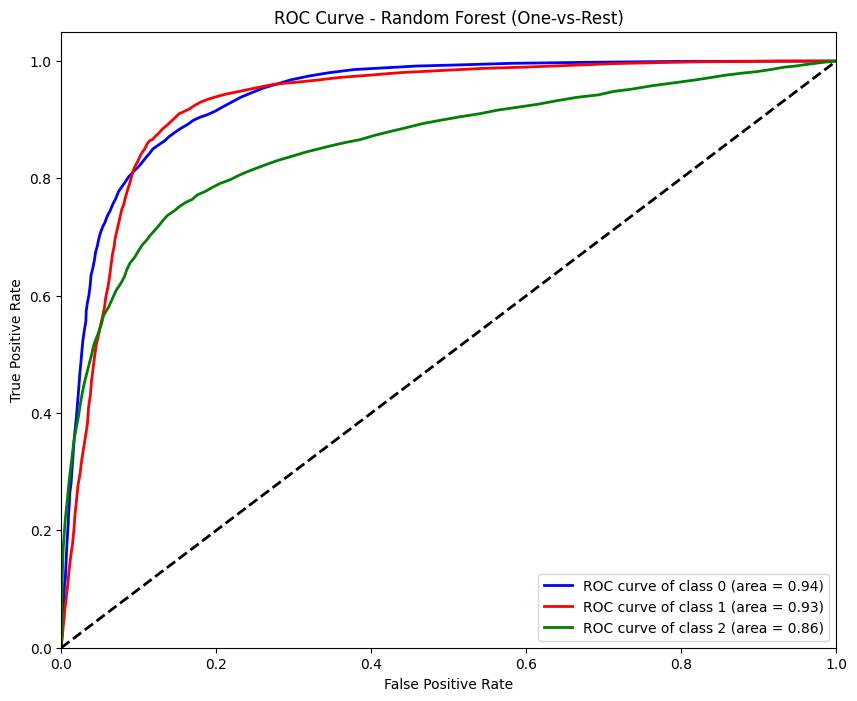

In [17]:
# ROC Curve for multi-class using One-vs-Rest
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for each class
y_score = rf_model.predict_proba(X_test)

# Get the number of classes
n_classes = len(rf_model.classes_)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test, y_score[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green'] # Define colors for each class
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()